## Alpha vs Beta Clone/Fidelity Comparison

### Generate 30-clone alpha/beta distributions
These distributions are generated with `virtual_lab.py` and were shaped so the
pilot-fidelity performance has the requested profiles (alpha: diverse/stepwise;
beta: smooth/gradual).


Saved: /Users/Laura/repo/mf-bo4bio/plots_pdf/alpha_beta_clone_fidelity_comparison.pdf


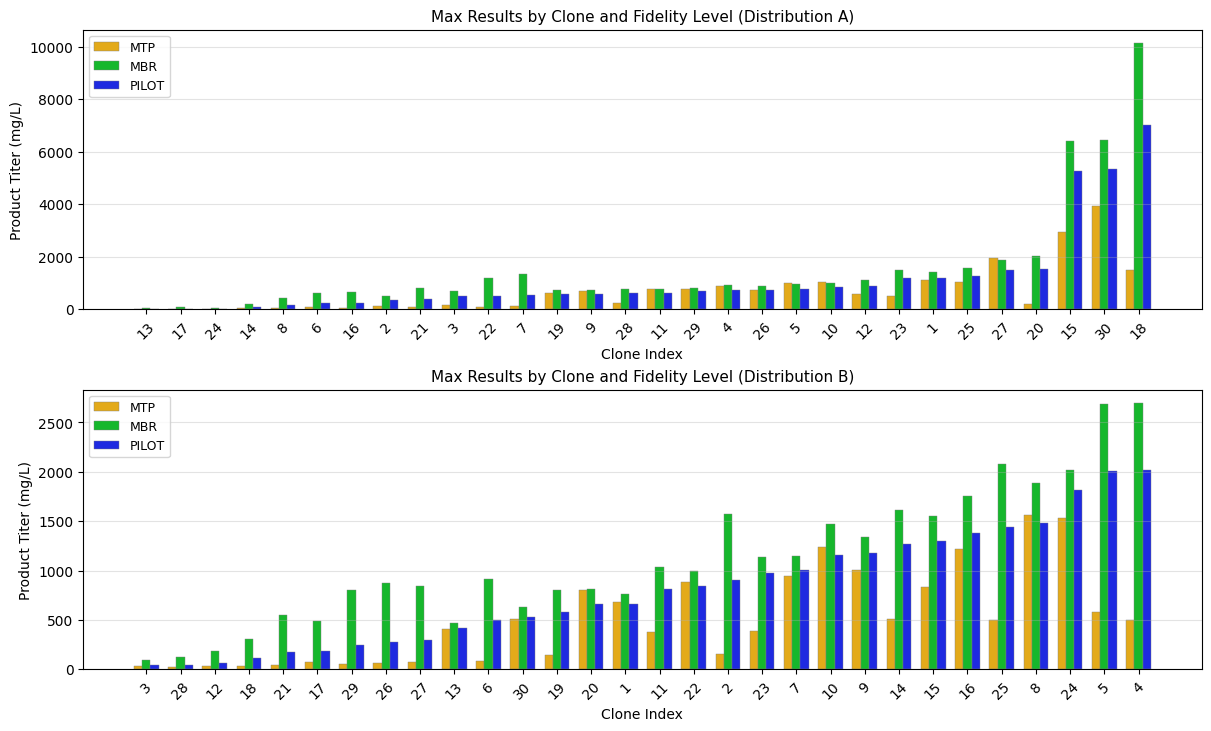

In [1]:
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import mfbo4bio.conditions_data as data
from mfbo4bio import virtual_lab as vl
from mfbo4bio.results import project_root
from mfbo4bio.utils import sampling

SEED = 12
NUM_SAMPLES = 6000
FEEDING_MAX = 50
FIDELITY_LEVELS = [0, 7, 10]
FIDELITY_DISTRIBUTION = {0: 0.33, 7: 0.33, 10: 0.33}
COLORS = {0: "#E3AA1A", 7: "#16B72C", 10: "#1E2AE0"}
LABELS = {0: "MTP", 7: "MBR", 10: "PILOT"}
SAVE_PDF = True
PDF_NAME = "alpha_beta_clone_fidelity_comparison.pdf"
PDF_DIR = project_root() / "plots_pdf"


def _n_clones_for_distribution(dist_name: str) -> int:
    attr_name = f"process_parameters_{dist_name}"
    if hasattr(data, attr_name):
        return len(getattr(data, attr_name).keys())

    # Fallback for older data modules
    if hasattr(data, "process_parameters"):
        return len(data.process_parameters.keys())

    raise AttributeError(
        f"No process parameter mapping found for "
        f"distribution '{dist_name}'."
    )


def _simulate_distribution(dist_name: str):
    n_clones = _n_clones_for_distribution(dist_name)

    dimensions_dict = {
        "temperature": ("continuous", (30, 40)),
        "ph": ("continuous", (6.0, 8.0)),
        "feeding1": ("continuous", (0, FEEDING_MAX)),
        "feeding2": ("continuous", (0, FEEDING_MAX)),
        "feeding3": ("continuous", (0, FEEDING_MAX)),
        "fidelity": ("discrete", FIDELITY_LEVELS),
        "clone": ("discrete", list(range(n_clones))),
    }

    constraints = {
        "feeding_max": FEEDING_MAX,
        "feeding_dims": ["feeding1", "feeding2", "feeding3"],
    }

    inputs = sampling(
        method="latin_hypercube",
        dimensions_dict=dimensions_dict,
        num_samples=NUM_SAMPLES,
        constraints=constraints,
        fidelity_distribution=FIDELITY_DISTRIBUTION,
        seed=SEED,
    )

    outputs = vl.conduct_experiment(inputs, clone_distribution=dist_name)

    if hasattr(inputs, "detach"):
        inputs_np = inputs.detach().cpu().numpy()
    else:
        inputs_np = np.asarray(inputs)
    if hasattr(outputs, "detach"):
        outputs_np = outputs.detach().cpu().numpy()
    else:
        outputs_np = np.asarray(outputs)

    return inputs_np, outputs_np


def _max_by_clone_and_fidelity(inputs_np: np.ndarray, outputs_np: np.ndarray):
    grouped = defaultdict(list)
    for x, y in zip(inputs_np, outputs_np):
        clone = int(x[6]) + 1 #convert 0-index back to celltype_1 naming
        fidelity = int(x[5])
        grouped[(clone, fidelity)].append(float(y))

    all_clones = sorted({clone for (clone, _) in grouped.keys()})
    clone_pilot_max = {
        clone: np.max(grouped.get((clone, 10), [0.0]))
        for clone in all_clones
    }
    sorted_clones = sorted(all_clones, key=lambda c: clone_pilot_max[c])

    maxima = {
        fidelity: [
            np.max(grouped.get((clone, fidelity), [0.0]))
            for clone in sorted_clones
        ]
        for fidelity in FIDELITY_LEVELS
    }
    return sorted_clones, maxima


def _plot_distribution(ax, dist_name: str, sorted_clones, maxima):
    x = np.arange(len(sorted_clones))
    width = 0.24
    offsets = {0: -width, 7: 0.0, 10: width}

    for fidelity in FIDELITY_LEVELS:
        ax.bar(
            x + offsets[fidelity],
            maxima[fidelity],
            width=width,
            label=LABELS[fidelity],
            color=COLORS[fidelity],
            edgecolor="gray",
            linewidth=0.3,
        )

    label_suffix = "A" if dist_name == "alpha" else "B"

    max_value = max(max(maxima[fidelity]) for fidelity in FIDELITY_LEVELS)
    # if max_value > 400:
    #     ax.set_ylim(0, 2200)

    ax.set_title(
        f"Max Results by Clone and Fidelity Level "
        f"(Distribution {label_suffix})",
        fontsize=11,
    )
    ax.set_ylabel("Product Titer (mg/L)")
    ax.set_xticks(x)
    ax.set_xticklabels(sorted_clones, rotation=45)
    ax.set_xlabel("Clone Index")
    ax.grid(axis="y", alpha=0.35)
    ax.legend(loc="upper left", fontsize=9)


alpha_inputs, alpha_outputs = _simulate_distribution("alpha")
beta_inputs, beta_outputs = _simulate_distribution("beta")

alpha_sorted_clones, alpha_maxima = _max_by_clone_and_fidelity(
    alpha_inputs, alpha_outputs
)
beta_sorted_clones, beta_maxima = _max_by_clone_and_fidelity(beta_inputs, beta_outputs)

fig, axes = plt.subplots(2, 1, figsize=(12, 7.2), constrained_layout=True)
_plot_distribution(axes[0], "alpha", alpha_sorted_clones, alpha_maxima)
_plot_distribution(axes[1], "beta", beta_sorted_clones, beta_maxima)

if SAVE_PDF:
    PDF_DIR.mkdir(parents=True, exist_ok=True)
    out_path = Path(PDF_DIR) / PDF_NAME
    fig.savefig(out_path, format="pdf", bbox_inches="tight")
    print(f"Saved: {out_path}")

plt.show()

Saved: /Users/Laura/repo/mf-bo4bio/plots_pdf/alpha_beta_clone_fidelity_comparison.pdf


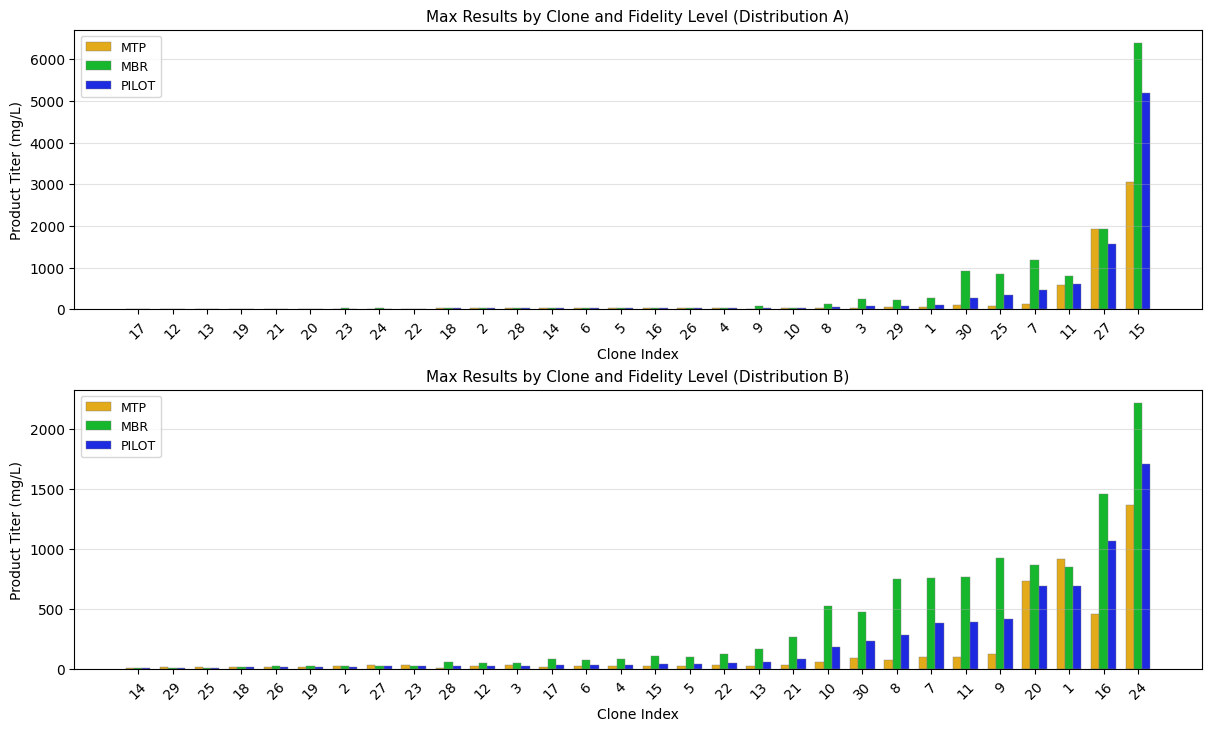

In [2]:
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import mfbo4bio.conditions_data as data
from mfbo4bio import config, virtual_lab as vl
from mfbo4bio.results import project_root
from mfbo4bio.utils import sampling

SEED = 12
NUM_SAMPLES = 6000
FEEDING_MAX = 50
FIDELITY_LEVELS = [0, 7, 10]
FIDELITY_DISTRIBUTION = {0: 0.33, 7: 0.33, 10: 0.33}
COLORS = {0: "#E3AA1A", 7: "#16B72C", 10: "#1E2AE0"}
LABELS = {0: "MTP", 7: "MBR", 10: "PILOT"}
SAVE_PDF = True
PDF_NAME = "alpha_beta_clone_fidelity_comparison.pdf"
PDF_DIR = project_root() / "plots_pdf"


def _n_clones_for_distribution(dist_name: str) -> int:
    attr_name = f"process_parameters_{dist_name}"
    if hasattr(data, attr_name):
        return len(getattr(data, attr_name).keys())

    # Fallback for older data modules
    if hasattr(data, "process_parameters"):
        return len(data.process_parameters.keys())

    raise AttributeError(
        f"No process parameter mapping found for "
        f"distribution '{dist_name}'."
    )


def _simulate_distribution(dist_name: str):
    n_clones = _n_clones_for_distribution(dist_name)

    t0 = 35
    ph0 = 7.2
    feeding_max = 50.0

    constraints = {
        "feeding_max": feeding_max,
        "feeding_dims": ["feeding1", "feeding2", "feeding3"],
    }

    # Range of pH and Temp is chosen very narrowly on purpose
    # to mimic platform conditions in industrial application
    dimensions_dict = {
        "temperature": ("continuous", (t0 - 0.0001, t0)),
        "ph": ("continuous", (ph0 - 0.0001, ph0)),
        "feeding1": ("continuous", (0, feeding_max)),
        "feeding2": ("continuous", (0, 0)),
        "feeding3": ("continuous", (0, 0)),
        "fidelity": ("discrete", [0, 7, 10]),
        "clone": ("discrete", list(range(30))),
    }

    inputs = sampling(
        method="latin_hypercube",
        dimensions_dict=dimensions_dict,
        num_samples=NUM_SAMPLES,
        constraints=constraints,
        fidelity_distribution=FIDELITY_DISTRIBUTION,
        seed=SEED,
    )

    outputs = vl.conduct_experiment(inputs, clone_distribution=dist_name)

    if hasattr(inputs, "detach"):
        inputs_np = inputs.detach().cpu().numpy()
    else:
        inputs_np = np.asarray(inputs)
    if hasattr(outputs, "detach"):
        outputs_np = outputs.detach().cpu().numpy()
    else:
        outputs_np = np.asarray(outputs)

    return inputs_np, outputs_np


def _max_by_clone_and_fidelity(inputs_np: np.ndarray, outputs_np: np.ndarray):
    grouped = defaultdict(list)
    for x, y in zip(inputs_np, outputs_np):
        clone = int(x[6]) + 1 #convert 0-index back to celltype_1 naming
        fidelity = int(x[5])
        grouped[(clone, fidelity)].append(float(y))

    all_clones = sorted({clone for (clone, _) in grouped.keys()})
    clone_pilot_max = {
        clone: np.max(grouped.get((clone, 10), [0.0]))
        for clone in all_clones
    }
    sorted_clones = sorted(all_clones, key=lambda c: clone_pilot_max[c])

    maxima = {
        fidelity: [
            np.max(grouped.get((clone, fidelity), [0.0]))
            for clone in sorted_clones
        ]
        for fidelity in FIDELITY_LEVELS
    }
    return sorted_clones, maxima


def _plot_distribution(ax, dist_name: str, sorted_clones, maxima):
    x = np.arange(len(sorted_clones))
    width = 0.24
    offsets = {0: -width, 7: 0.0, 10: width}

    for fidelity in FIDELITY_LEVELS:
        ax.bar(
            x + offsets[fidelity],
            maxima[fidelity],
            width=width,
            label=LABELS[fidelity],
            color=COLORS[fidelity],
            edgecolor="gray",
            linewidth=0.3,
        )

    label_suffix = "A" if dist_name == "alpha" else "B"

    max_value = max(max(maxima[fidelity]) for fidelity in FIDELITY_LEVELS)
    # if max_value > 400:
    #     ax.set_ylim(0, 2200)

    ax.set_title(
        f"Max Results by Clone and Fidelity Level "
        f"(Distribution {label_suffix})",
        fontsize=11,
    )
    ax.set_ylabel("Product Titer (mg/L)")
    ax.set_xticks(x)
    ax.set_xticklabels(sorted_clones, rotation=45)
    ax.set_xlabel("Clone Index")
    ax.grid(axis="y", alpha=0.35)
    ax.legend(loc="upper left", fontsize=9)


alpha_inputs, alpha_outputs = _simulate_distribution("alpha")
beta_inputs, beta_outputs = _simulate_distribution("beta")

alpha_sorted_clones, alpha_maxima = _max_by_clone_and_fidelity(
    alpha_inputs, alpha_outputs
)
beta_sorted_clones, beta_maxima = _max_by_clone_and_fidelity(beta_inputs, beta_outputs)

fig, axes = plt.subplots(2, 1, figsize=(12, 7.2), constrained_layout=True)
_plot_distribution(axes[0], "alpha", alpha_sorted_clones, alpha_maxima)
_plot_distribution(axes[1], "beta", beta_sorted_clones, beta_maxima)

if SAVE_PDF:
    PDF_DIR.mkdir(parents=True, exist_ok=True)
    out_path = Path(PDF_DIR) / PDF_NAME
    fig.savefig(out_path, format="pdf", bbox_inches="tight")
    print(f"Saved: {out_path}")

plt.show()   

In [3]:
import numpy as np
from scipy.stats import pearsonr, spearmanr


keys = [0, 7, 10]
arr = {k: np.array(v) for k, v in alpha_maxima.items()}
pairs = [(a, b) for i, a in enumerate(keys) for b in keys[i+1:]]

# --- Overall Correlations ---
print("=" * 60)
print("OVERALL PEARSON CORRELATIONS")
print("=" * 60)
for a, b in pairs:
    r, p = pearsonr(arr[a], arr[b])
    print(f"  Reactor {a} vs Reactor {b}: r = {r:.4f}  (p = {p:.4f})")

print()
print("=" * 60)
print("OVERALL SPEARMAN CORRELATIONS")
print("=" * 60)
for a, b in pairs:
    r, p = spearmanr(arr[a], arr[b])
    print(f"  Reactor {a} vs Reactor {b}: r = {r:.4f}  (p = {p:.4f})")

# --- Per-Entry Correlations ---
n = len(next(iter(arr.values())))

print()
print("=" * 60)
print("PER-ENTRY CORRELATION (across reactors at each index)")
print("=" * 60)
header = f"{'Entry':<8} " + "  ".join(f"Reactor {k}" for k in keys) + f"  {'Pearson r':<12} {'Spearman r'}"
print(header)
print("-" * len(header))

for i in range(n):
    vals = [arr[k][i] for k in keys]
    r_p, _ = pearsonr(keys, vals)
    r_s, _ = spearmanr(keys, vals)
    val_str = "  ".join(f"{v:>10.2f}" for v in vals)
    print(f"  {i:<6} {val_str}   {r_p:>+.4f}      {r_s:>+.4f}")

OVERALL PEARSON CORRELATIONS
  Reactor 0 vs Reactor 7: r = 0.9382  (p = 0.0000)
  Reactor 0 vs Reactor 10: r = 0.9583  (p = 0.0000)
  Reactor 7 vs Reactor 10: r = 0.9901  (p = 0.0000)

OVERALL SPEARMAN CORRELATIONS
  Reactor 0 vs Reactor 7: r = 0.8719  (p = 0.0000)
  Reactor 0 vs Reactor 10: r = 0.9341  (p = 0.0000)
  Reactor 7 vs Reactor 10: r = 0.9671  (p = 0.0000)

PER-ENTRY CORRELATION (across reactors at each index)
Entry    Reactor 0  Reactor 7  Reactor 10  Pearson r    Spearman r
------------------------------------------------------------------
  0            6.35        4.70        4.44   -0.9857      -1.0000
  1            4.68        9.51        4.63   +0.2157      -0.5000
  2            6.64       11.56        6.38   +0.1823      -0.5000
  3           11.26        9.05        8.26   -0.9991      -1.0000
  4           11.32        8.52        8.36   -0.9691      -1.0000
  5           13.67       10.23       10.11   -0.9646      -1.0000
  6            9.98       21.01       1

In [4]:
import numpy as np
from scipy.stats import pearsonr, spearmanr


keys = [0, 7, 10]
arr = {k: np.array(v) for k, v in beta_maxima.items()}
pairs = [(a, b) for i, a in enumerate(keys) for b in keys[i+1:]]

# --- Overall Correlations ---
print("=" * 60)
print("OVERALL PEARSON CORRELATIONS")
print("=" * 60)
for a, b in pairs:
    r, p = pearsonr(arr[a], arr[b])
    print(f"  Reactor {a} vs Reactor {b}: r = {r:.4f}  (p = {p:.4f})")

print()
print("=" * 60)
print("OVERALL SPEARMAN CORRELATIONS")
print("=" * 60)
for a, b in pairs:
    r, p = spearmanr(arr[a], arr[b])
    print(f"  Reactor {a} vs Reactor {b}: r = {r:.4f}  (p = {p:.4f})")

# --- Per-Entry Correlations ---
n = len(next(iter(arr.values())))

print()
print("=" * 60)
print("PER-ENTRY CORRELATION (across reactors at each index)")
print("=" * 60)
header = f"{'Entry':<8} " + "  ".join(f"Reactor {k}" for k in keys) + f"  {'Pearson r':<12} {'Spearman r'}"
print(header)
print("-" * len(header))

for i in range(n):
    vals = [arr[k][i] for k in keys]
    r_p, _ = pearsonr(keys, vals)
    r_s, _ = spearmanr(keys, vals)
    val_str = "  ".join(f"{v:>10.2f}" for v in vals)
    print(f"  {i:<6} {val_str}   {r_p:>+.4f}      {r_s:>+.4f}")

OVERALL PEARSON CORRELATIONS
  Reactor 0 vs Reactor 7: r = 0.8305  (p = 0.0000)
  Reactor 0 vs Reactor 10: r = 0.9149  (p = 0.0000)
  Reactor 7 vs Reactor 10: r = 0.9735  (p = 0.0000)

OVERALL SPEARMAN CORRELATIONS
  Reactor 0 vs Reactor 7: r = 0.8345  (p = 0.0000)
  Reactor 0 vs Reactor 10: r = 0.8825  (p = 0.0000)
  Reactor 7 vs Reactor 10: r = 0.9871  (p = 0.0000)

PER-ENTRY CORRELATION (across reactors at each index)
Entry    Reactor 0  Reactor 7  Reactor 10  Pearson r    Spearman r
------------------------------------------------------------------
  0            8.42        8.74        6.96   -0.6053      -0.5000
  1           15.37       11.44       11.36   -0.9616      -1.0000
  2           16.35       11.52       11.39   -0.9625      -1.0000
  3           21.28       17.51       15.51   -0.9987      -1.0000
  4           19.48       28.12       17.06   +0.0167      -0.5000
  5           21.96       29.43       20.09   +0.0366      -0.5000
  6           30.60       24.48       2